In [1]:
import pandas as pd

In [ ]:
# 读取CSV文件（使用分号作为分隔符，逗号作为千位分隔符）
df = pd.read_csv('../Data/Actual_consumption_201901010000_202603240000_Quarterhour.csv', 
                  sep=';', 
                  decimal=',')

# 查看前几行
print(df.head())


             Start date              End date  \
0  Jan 1, 2019 12:00 AM  Jan 1, 2019 12:15 AM   
1  Jan 1, 2019 12:15 AM  Jan 1, 2019 12:30 AM   
2  Jan 1, 2019 12:30 AM  Jan 1, 2019 12:45 AM   
3  Jan 1, 2019 12:45 AM   Jan 1, 2019 1:00 AM   
4   Jan 1, 2019 1:00 AM   Jan 1, 2019 1:15 AM   

  grid load [MWh] Original resolutions  \
0                            11,002.25   
1                            10,865.50   
2                            10,733.75   
3                            10,672.25   
4                            10,595.75   

  Grid load incl. hydro pumped storage [MWh] Original resolutions  \
0                                          11,435.25                
1                                          11,145.50                
2                                          11,001.50                
3                                          10,964.50                
4                                          10,832.00                

  Hydro pumped storage [MWh] Original

In [3]:
print(f"\n数据形状: {df.shape}")


数据形状: (253344, 6)


In [4]:
print(f"\n列名: {df.columns.tolist()}")


列名: ['Start date', 'End date', 'grid load [MWh] Original resolutions', 'Grid load incl. hydro pumped storage [MWh] Original resolutions', 'Hydro pumped storage [MWh] Original resolutions', 'Residual load [MWh] Original resolutions']


In [5]:
print(f"\n数据类型:\n{df.dtypes}")


数据类型:
Start date                                                         str
End date                                                           str
grid load [MWh] Original resolutions                               str
Grid load incl. hydro pumped storage [MWh] Original resolutions    str
Hydro pumped storage [MWh] Original resolutions                    str
Residual load [MWh] Original resolutions                           str
dtype: object


In [6]:
# pandas已经通过decimal=',' 自动处理了数字转换
# 现在只需要处理日期列
df['Start date'] = pd.to_datetime(df['Start date'])
df['End date'] = pd.to_datetime(df['End date'])

# 检查转换后的结果
print(df.dtypes)
print("\n前几行数据：")
print(df.head())
print(f"\n数据形状: {df.shape}")

/tmp/ipykernel_6818/1932606944.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start date'] = pd.to_datetime(df['Start date'])
/tmp/ipykernel_6818/1932606944.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['End date'] = pd.to_datetime(df['End date'])


Start date                                                         datetime64[us]
End date                                                           datetime64[us]
grid load [MWh] Original resolutions                                          str
Grid load incl. hydro pumped storage [MWh] Original resolutions               str
Hydro pumped storage [MWh] Original resolutions                               str
Residual load [MWh] Original resolutions                                      str
dtype: object

前几行数据：
           Start date            End date  \
0 2019-01-01 00:00:00 2019-01-01 00:15:00   
1 2019-01-01 00:15:00 2019-01-01 00:30:00   
2 2019-01-01 00:30:00 2019-01-01 00:45:00   
3 2019-01-01 00:45:00 2019-01-01 01:00:00   
4 2019-01-01 01:00:00 2019-01-01 01:15:00   

  grid load [MWh] Original resolutions  \
0                            11,002.25   
1                            10,865.50   
2                            10,733.75   
3                            10,672.25   
4    

In [7]:
# 1. 自动识别需要转换的列（跳过前两个日期列）
value_columns = df.columns[2:]

for col in value_columns:
    # 第一步：去掉逗号 (str.replace)
    # 第二步：转换为浮点数 (astype(float))
    # 注意：如果数据中有 '-' 或空值，使用 pd.to_numeric(..., errors='coerce') 会更安全
    df[col] = pd.to_numeric(df[col].str.replace(',', ''), errors='coerce')

# 2. 顺手把那些巨长无比的列名改短
# 我们只保留 [MWh] 之前的核心单词，并转为小写加下划线
new_column_names = {col: col.split(' [')[0].lower().replace(' ', '_') for col in value_columns}
df.rename(columns=new_column_names, inplace=True)

# 3. 再次检查结果
print(df.dtypes)
print(df.head())

Start date                              datetime64[us]
End date                                datetime64[us]
grid_load                                      float64
grid_load_incl._hydro_pumped_storage           float64
hydro_pumped_storage                           float64
residual_load                                  float64
dtype: object
           Start date            End date  grid_load  \
0 2019-01-01 00:00:00 2019-01-01 00:15:00   11002.25   
1 2019-01-01 00:15:00 2019-01-01 00:30:00   10865.50   
2 2019-01-01 00:30:00 2019-01-01 00:45:00   10733.75   
3 2019-01-01 00:45:00 2019-01-01 01:00:00   10672.25   
4 2019-01-01 01:00:00 2019-01-01 01:15:00   10595.75   

   grid_load_incl._hydro_pumped_storage  hydro_pumped_storage  residual_load  
0                              11435.25                433.00        5383.00  
1                              11145.50                280.00        5066.75  
2                              11001.50                267.75        4748.00  
3  

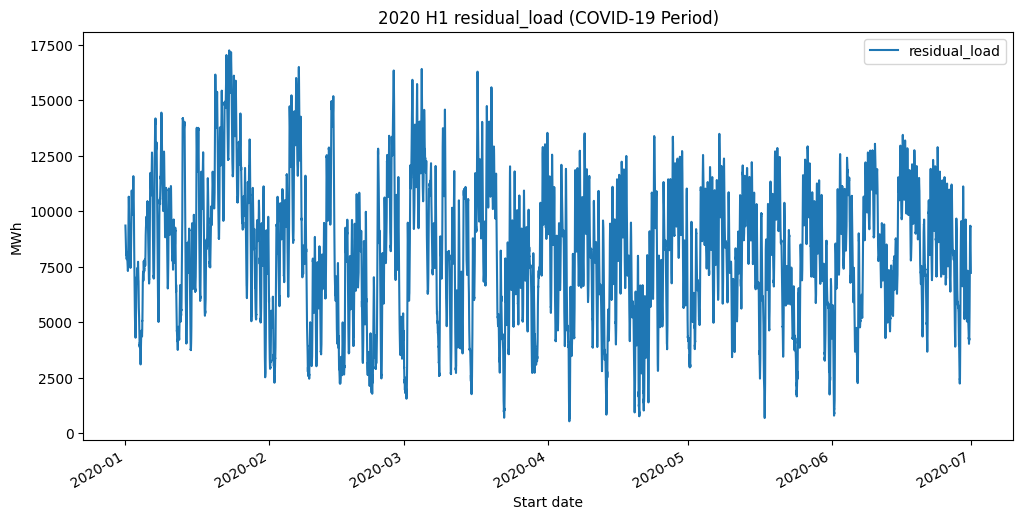

In [ ]:
import matplotlib.pyplot as plt

# 设置时间为索引，并排序（必须排序才能用字符串切片日期范围）
df_plot = df.set_index('Start date').sort_index()

# 绘制 2020 年上半年的residual_load
df_plot.loc['2020-01-01':'2020-06-30', ['residual_load']].plot(figsize=(12, 6))
plt.title("2020 H1 residual_load (COVID-19 Period)")
plt.ylabel("MWh")
plt.show()

# 2020 年的上半年的wind_onshore第一季度是明显走高的， 第二季度是photovoltaics明显占上风的。-》 第一季度（Q1）多风，第二季度（Q2）多光，这完美符合欧洲的季节性气候特征：春季气旋带来强风，夏季高压带来充足日照。

In [9]:
# 获取当前 df 中实际的数值列（重命名后的列名，跳过前两个日期列）
current_value_columns = df.columns[2:]

# 1. 检查是否存在负值
negative_vals = (df[current_value_columns] < 0).sum()
print("负值统计：\n", negative_vals[negative_vals > 0])

# 2. 检查时间戳是否连续（注意：日期列名是 'Start date'，未被重命名）
time_diffs = df['Start date'].diff().dropna()
# 找出不是 15 分钟的间隔
gaps = time_diffs[time_diffs != pd.Timedelta(minutes=15)]
if gaps.empty:
    print("\n时间戳连续，无断层 ✓")
else:
    print(f"\n警告：发现 {len(gaps)} 处时间断层！")
    print(gaps)

#无负值 ✓
#发现 14 处时间断层：这是由德国夏令时（DST）切换导致的正常现象——
#+1:15 的断层 = 夏令时结束（时钟拨回，出现重复时间戳，跳过了 1 个 15 分钟间隔）
#-0:45（即 -1 days +23:15）= 夏令时开始（时钟拨前，少了 1 个 15 分钟间隔）
#每年 2 次切换 × 7 年数据 = 14 处，完全符合预期，数据本身没有问题。

负值统计：
 residual_load    1413
dtype: int64

警告：发现 14 处时间断层！
8552       0 days 01:15:00
28712    -1 days +23:15:00
43496      0 days 01:15:00
63656    -1 days +23:15:00
78440      0 days 01:15:00
99272    -1 days +23:15:00
113384     0 days 01:15:00
134216   -1 days +23:15:00
148328     0 days 01:15:00
169160   -1 days +23:15:00
183944     0 days 01:15:00
204104   -1 days +23:15:00
218888     0 days 01:15:00
239048   -1 days +23:15:00
Name: Start date, dtype: timedelta64[us]


In [10]:
# 1. 告诉 Pandas 现在的 Start date 是欧洲/柏林时间
# ambiguous='infer' 尝试自动处理 10 月重复的那一小时
# nonexistent='shift_forward' 处理 3 月消失的那一小时
df['start_date_utc'] = pd.to_datetime(df['Start date']).dt.tz_localize(
    'Europe/Berlin', 
    ambiguous='infer', 
    nonexistent='shift_forward'
).dt.tz_convert('UTC')

# 2. 转换后再次检查断层
time_diffs_utc = df['start_date_utc'].diff().dropna()
gaps_utc = time_diffs_utc[time_diffs_utc != pd.Timedelta(minutes=15)]

if gaps_utc.empty:
    print("✅ 完美！转换为 UTC 后，时间轴已完全连续，无断层。")
else:
    print(f"仍然存在 {len(gaps_utc)} 处非 DST 导致的异常断层。")

✅ 完美！转换为 UTC 后，时间轴已完全连续，无断层。


In [11]:
#检查 End date 的连续性
time_diffs = df['End date'].diff().dropna()
# 找出不是 15 分钟的间隔
gaps = time_diffs[time_diffs != pd.Timedelta(minutes=15)]
if gaps.empty:
    print("\n时间戳连续，无断层 ✓")
else:
    print(f"\n警告：发现 {len(gaps)} 处时间断层！")
    print(gaps)
# 出现21处
# End date 在夏令时结束时会出现跨 DST 边界的解析错误（End date 比 Start date 早约 23:45）
# 修复方法：直接从 Start date 推导 End date = Start date + 15 分钟
df['End date'] = df['Start date'] + pd.Timedelta(minutes=15)

# 验证修复结果
time_diffs_end = df['End date'].diff().dropna()
gaps_end = time_diffs_end[time_diffs_end != pd.Timedelta(minutes=15)]

time_diffs_start = df['Start date'].diff().dropna()
gaps_start = time_diffs_start[time_diffs_start != pd.Timedelta(minutes=15)]

print(f"Start date 断层数: {len(gaps_start)}（均为正常 DST 切换）")
print(f"End date   断层数: {len(gaps_end)}（修复后应与 Start date 一致）")

# 验证 End date - Start date 始终为 15 分钟
diffs = df['End date'] - df['Start date']
assert (diffs == pd.Timedelta(minutes=15)).all(), "存在异常！"
print("\n✅ End date 已修复：End date - Start date 全部等于 15 分钟")


警告：发现 21 处时间断层！
8551     -1 days +00:15:00
8552       1 days 01:15:00
28712    -1 days +23:15:00
43495    -1 days +00:15:00
43496      1 days 01:15:00
63656    -1 days +23:15:00
78439    -1 days +00:15:00
78440      1 days 01:15:00
99272    -1 days +23:15:00
113383   -1 days +00:15:00
113384     1 days 01:15:00
134216   -1 days +23:15:00
148327   -1 days +00:15:00
148328     1 days 01:15:00
169160   -1 days +23:15:00
183943   -1 days +00:15:00
183944     1 days 01:15:00
204104   -1 days +23:15:00
218887   -1 days +00:15:00
218888     1 days 01:15:00
239048   -1 days +23:15:00
Name: End date, dtype: timedelta64[us]
Start date 断层数: 14（均为正常 DST 切换）
End date   断层数: 14（修复后应与 Start date 一致）

✅ End date 已修复：End date - Start date 全部等于 15 分钟


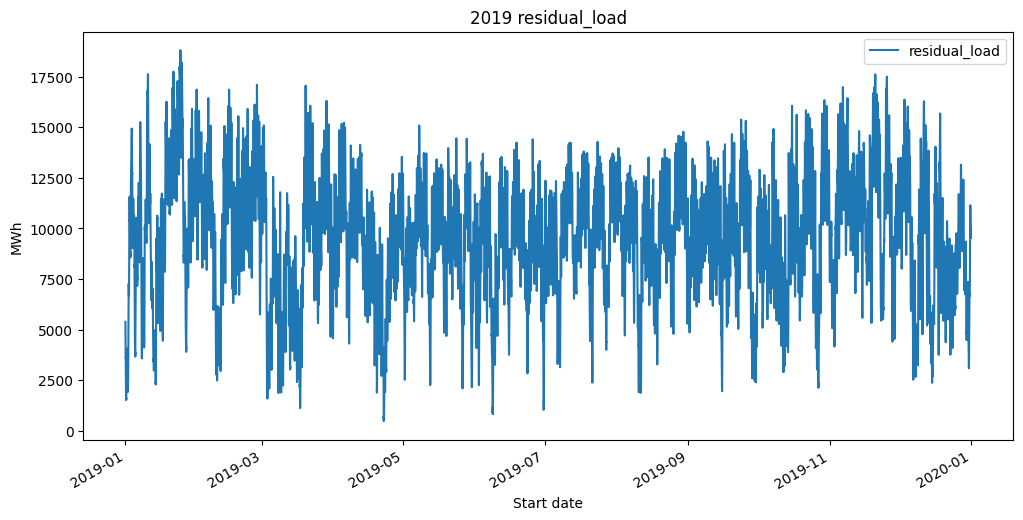

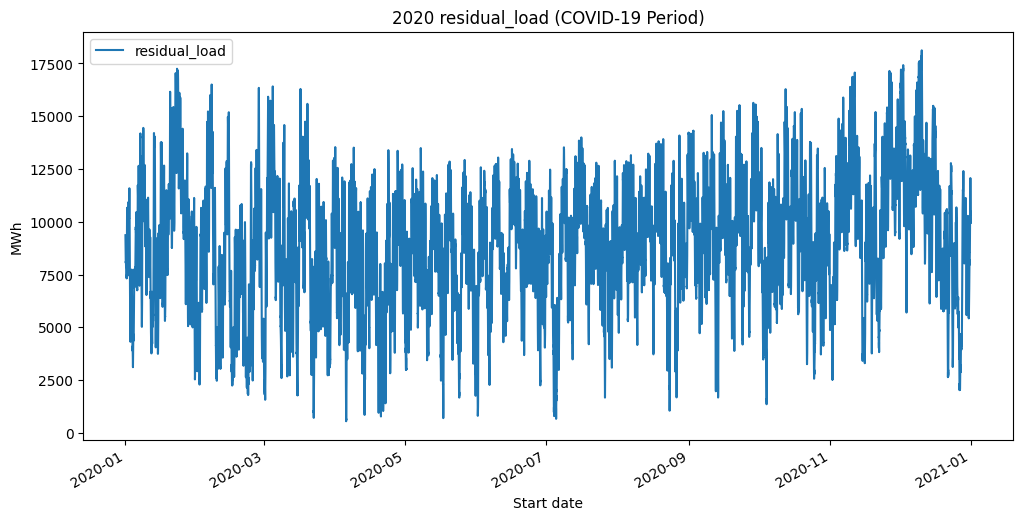

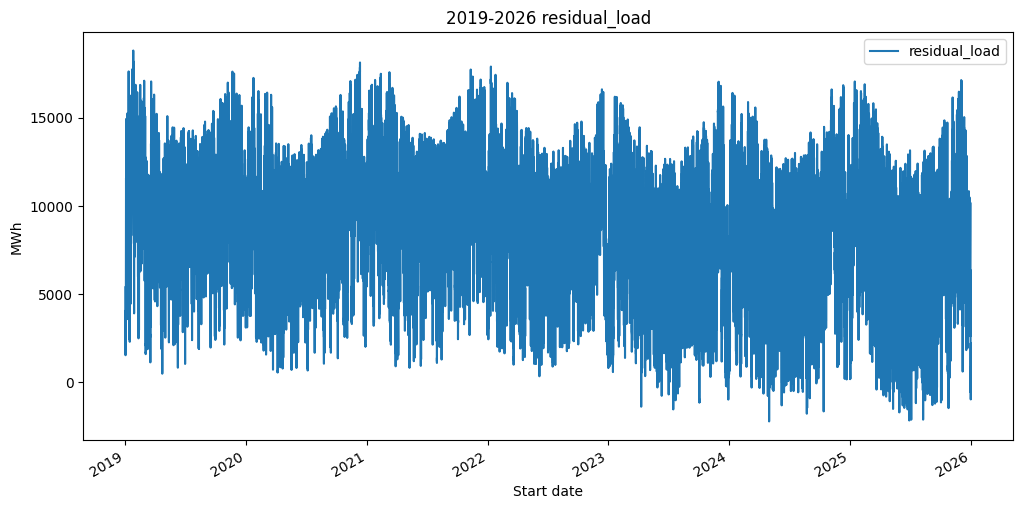

In [12]:

# 设置时间为索引，并排序（必须排序才能用字符串切片日期范围）
df_plot = df.set_index('Start date').sort_index()
# 绘制 2019 年上半年的residual_load
df_plot.loc['2019-01-01':'2019-12-31', ['residual_load']].plot(figsize=(12, 6))
plt.title("2019 residual_load")
plt.ylabel("MWh")
plt.show()
# 绘制 2020 年上半年的residual_load
df_plot.loc['2020-01-01':'2020-12-31', ['residual_load']].plot(figsize=(12, 6))
plt.title("2020 residual_load (COVID-19 Period)")
plt.ylabel("MWh")
plt.show()
# 绘制 2019-2026 年的residual_load趋势
df_plot.loc['2019-01-01':'2026-01-01', ['residual_load']].plot(figsize=(12, 6))
plt.title("2019-2026 residual_load")
plt.ylabel("MWh")
plt.show()

In [13]:
df.columns

Index(['Start date', 'End date', 'grid_load',
       'grid_load_incl._hydro_pumped_storage', 'hydro_pumped_storage',
       'residual_load', 'start_date_utc'],
      dtype='str')

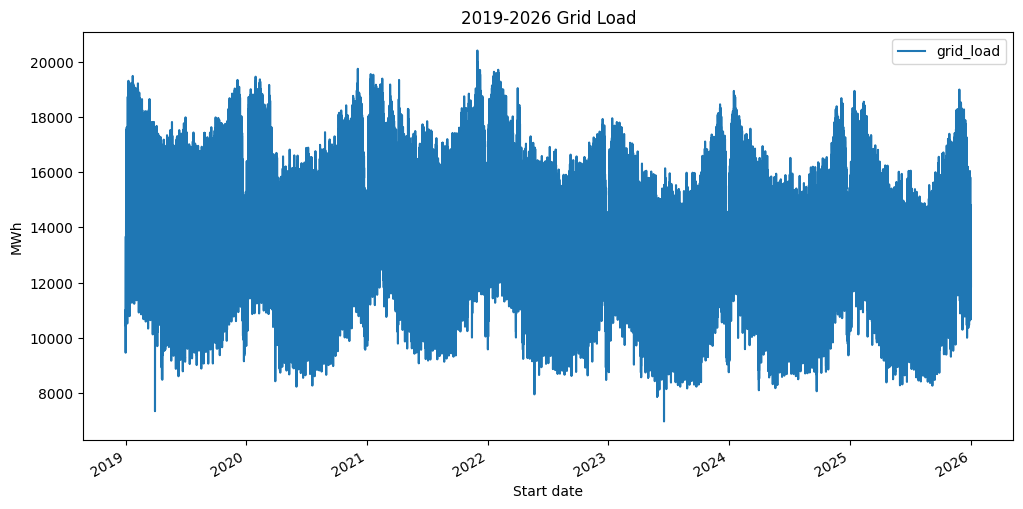

In [14]:
# 绘制 2019-2026 年grid_load的发电趋势
df_plot.loc['2019-01-01':'2026-01-01', ['grid_load']].plot(figsize=(12, 6))
plt.title("2019-2026 Grid Load")
plt.ylabel("MWh")
plt.show()